In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering

In [2]:
df = pd.read_csv("../data/Mall_Customers.csv")

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [3]:
X = df[
    [
        "Annual Income (k$)",
        "Spending Score (1-100)"
    ]
]

In [4]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

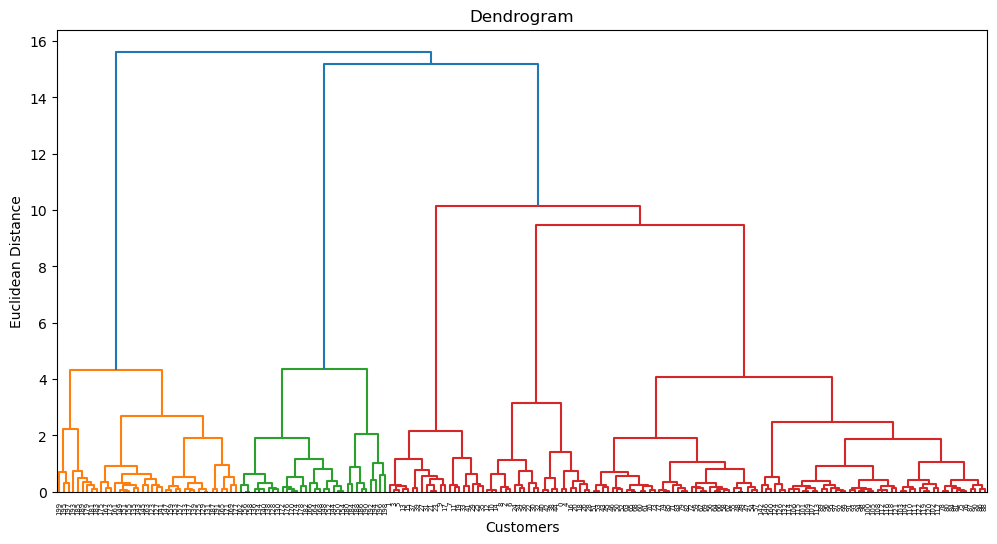

In [5]:
plt.figure(figsize=(12,6))

dendrogram(
    linkage(
        X_scaled,
        method="ward"
    )
)

plt.title("Dendrogram")
plt.xlabel("Customers")
plt.ylabel("Euclidean Distance")

plt.show()

In [6]:
hc = AgglomerativeClustering(
    n_clusters=5,
    metric="euclidean",
    linkage="ward"
)

clusters = hc.fit_predict(X_scaled)

clusters

array([4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3,
       4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 2,
       4, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 2, 1, 2, 1, 0, 1, 0, 1,
       2, 1, 0, 1, 0, 1, 0, 1, 0, 1, 2, 1, 0, 1, 2, 1, 0, 1, 0, 1, 0, 1,
       0, 1, 0, 1, 0, 1, 2, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1,
       0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1,
       0, 1])

In [7]:
df["Cluster"] = clusters

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,4
1,2,Male,21,15,81,3
2,3,Female,20,16,6,4
3,4,Female,23,16,77,3
4,5,Female,31,17,40,4


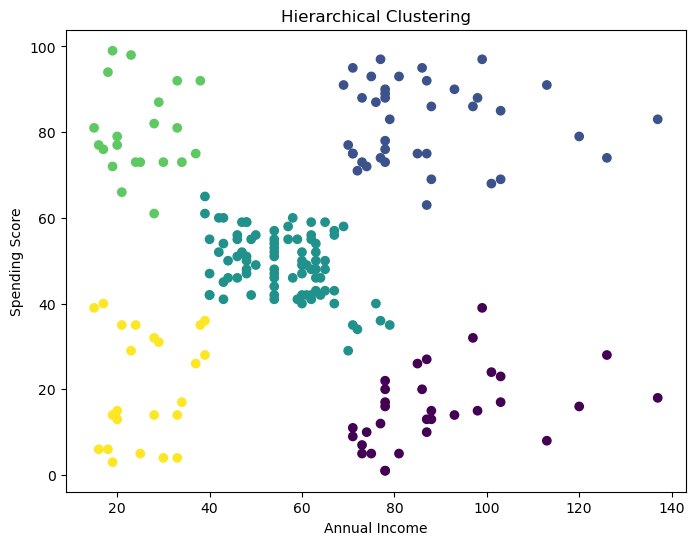

In [8]:
plt.figure(figsize=(8,6))

plt.scatter(
    X.iloc[:,0],
    X.iloc[:,1],
    c=clusters
)

plt.xlabel("Annual Income")

plt.ylabel("Spending Score")

plt.title(
    "Hierarchical Clustering"
)

plt.show()

In [9]:
import os
import joblib

os.makedirs("../models", exist_ok=True)

# Save clustered dataset
df.to_csv(
    "../models/clustered_customers.csv",
    index=False
)

# Save scaler
joblib.dump(
    scaler,
    "../models/scaler.pkl"
)

print("Files Saved Successfully")

Files Saved Successfully
